In [ ]:
import random
import numpy as np
import torch
from torch import nn

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [ ]:
import numpy as np
from sklearn.linear_model import SGDRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
n_samples, n_features = 10, 5
rng = np.random.RandomState(0)
y = rng.randn(n_samples)
X = rng.randn(n_samples, n_features)

reg = make_pipeline(StandardScaler(),
                    SGDRegressor(max_iter=1000, tol=1e-3))
reg.fit(X, y)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('sgdregressor', SGDRegressor())])

In [ ]:
import numpy as np
from typing import Callable


def gradient_descent(start: float, gradient: Callable[[float], float],
                    learn_rate: float, max_iter: int, tol: float = 0.01):
   x = start
   steps = [start]  # history tracking



   for _ in range(max_iter):
       diff = learn_rate*gradient(x)
       if np.abs(diff) < tol:
           break
       x = x - diff
       steps.append(x)  # history tracing


   return steps, x



In [ ]:
def f(x):
    return x**2

def grad_f(x):
    return 2 * x


def gradient_descent(x0, alpha, num_iters):
    x = x0

    print(f"Начальное значение: x0 = {x}\n")

    for i in range(1, num_iters + 1):
        grad = grad_f(x)
        x_new = x - alpha * grad

        print(f"Итерация {i}:")
        print(f"  x_{i-1} = {x}")
        print(f"  ∇f(x_{i-1}) = {grad}")
        print(f"  x_{i} = {x} - {alpha} * {grad} = {x_new}\n")

        x = x_new

    return x

gradient_descent(x0=5.0, alpha=0.1, num_iters=5)

Начальное значение: x0 = 5.0

Итерация 1:
  x_0 = 5.0
  ∇f(x_0) = 10.0
  x_1 = 5.0 - 0.1 * 10.0 = 4.0

Итерация 2:
  x_1 = 4.0
  ∇f(x_1) = 8.0
  x_2 = 4.0 - 0.1 * 8.0 = 3.2

Итерация 3:
  x_2 = 3.2
  ∇f(x_2) = 6.4
  x_3 = 3.2 - 0.1 * 6.4 = 2.56

Итерация 4:
  x_3 = 2.56
  ∇f(x_3) = 5.12
  x_4 = 2.56 - 0.1 * 5.12 = 2.048

Итерация 5:
  x_4 = 2.048
  ∇f(x_4) = 4.096
  x_5 = 2.048 - 0.1 * 4.096 = 1.6384



1.6384

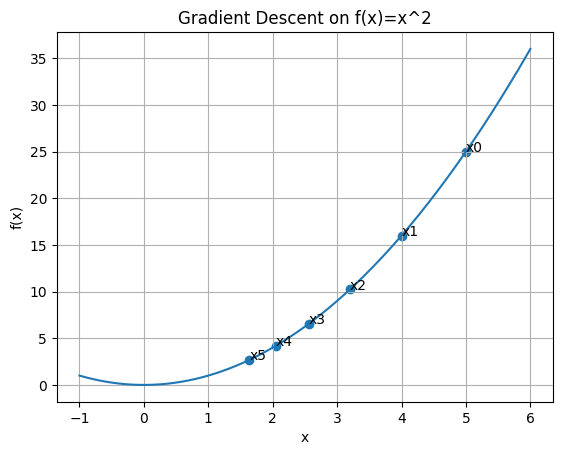

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x_vals = [5.0]
x = 5.0
alpha = 0.1

for _ in range(5):
    x = x - alpha * (2 * x)
    x_vals.append(x)


x_curve = np.linspace(-1, 6, 200)
y_curve = x_curve**2

plt.figure()
plt.plot(x_curve, y_curve)                     # график функции
plt.scatter(x_vals, [x**2 for x in x_vals])    # точки спуска

# подписи точек
for i, x in enumerate(x_vals):
    plt.text(x, x**2, f"x{i}")

plt.title("Gradient Descent on f(x)=x^2")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()

plt.show()

Градиентный спуск

In [ ]:
import numpy as np
from typing import Callable

def gradient_descent(start: float, gradient: Callable[[float], float],
                    learn_rate: float, max_iter: int, tol: float = 0.01):
   x = start
   steps = [start]  # history tracking



   for _ in range(max_iter):
       diff = learn_rate*gradient(x)
       if np.abs(diff) < tol:
           break
       x = x - diff
       steps.append(x)  # history tracing


   return steps, x



In [ ]:
def func1(x:float):
    return x**2

def gradient_func1(x:float):
    return 2*x

In [ ]:
history, result = gradient_descent(5, gradient_func1, 0.1, 100)

In [ ]:
print('Градиентный спуск по шагам:')
history

Градиентный спуск по шагам:


[5,
 4.0,
 3.2,
 2.56,
 2.048,
 1.6384,
 1.31072,
 1.0485760000000002,
 0.8388608000000002,
 0.6710886400000001,
 0.5368709120000001,
 0.4294967296000001,
 0.3435973836800001,
 0.27487790694400005,
 0.21990232555520003,
 0.17592186044416003,
 0.140737488355328,
 0.11258999068426241,
 0.09007199254740993,
 0.07205759403792794,
 0.057646075230342354,
 0.04611686018427388]

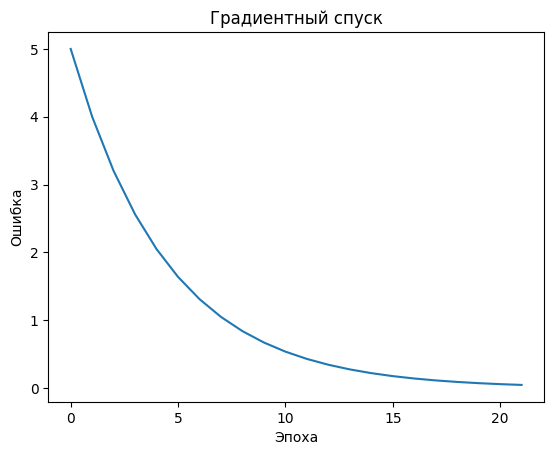

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history)
plt.xlabel("Эпоха")
plt.ylabel("Ошибка")
plt.title("Градиентный спуск")
plt.show()

# SGD

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
# создаём простой датасет
X = torch.randn(100, 1)
y = 3 * X + 2 + 0.1 * torch.randn(100, 1)

dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

In [ ]:
# модель
model_sgd = nn.Linear(1, 1)

criterion = nn.MSELoss() # в качестве функции потерь выбираем MSE
sgd_optimizer = torch.optim.SGD(model_sgd.parameters(), lr=0.1) # learning rate - 0,1

sgd_loss_history = [] # сюда записываем историю вычислений

# обучение
for epoch in range(10):
    epoch_loss = 0

    for X_batch, y_batch in dataloader:
        sgd_optimizer.zero_grad()             # обнуляем градиенты
        y_pred = model_sgd(X_batch)           # делаем предсказание
        loss = criterion(y_pred, y_batch) # вычисляем ошибку

        loss.backward()                   # вычисляем градиенты
        sgd_optimizer.step()                  # делаем шаг градиентного спуска

        epoch_loss += loss.item()         # записываем историю вычислений за конкретную итерацию

    # усредним loss по батчам за каждую итерацию и запишем в историю
    epoch_loss /= len(dataloader)
    sgd_loss_history.append(epoch_loss)

    print(f"Эпоха {epoch}: ошибка = {epoch_loss:.4f}")

Эпоха 0: ошибка = 3.0497
Эпоха 1: ошибка = 0.1076
Эпоха 2: ошибка = 0.0111
Эпоха 3: ошибка = 0.0079
Эпоха 4: ошибка = 0.0081
Эпоха 5: ошибка = 0.0078
Эпоха 6: ошибка = 0.0076
Эпоха 7: ошибка = 0.0084
Эпоха 8: ошибка = 0.0096
Эпоха 9: ошибка = 0.0076


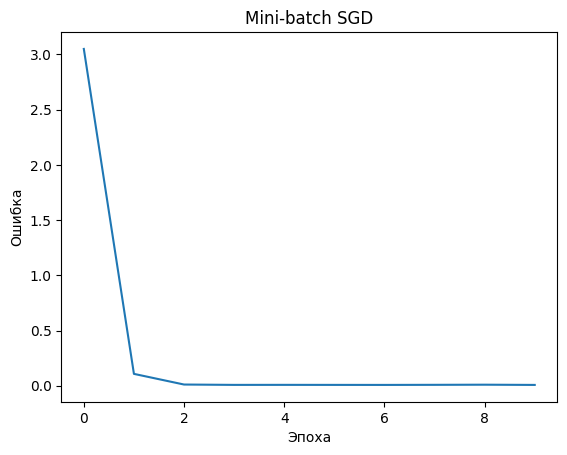

In [ ]:
import matplotlib.pyplot as plt

plt.plot(sgd_loss_history)
plt.xlabel("Эпоха")
plt.ylabel("Ошибка")
plt.title("Mini-batch SGD")
plt.show()

# Momentum

In [ ]:
# модель
momentum_model = nn.Linear(1, 1)

criterion = nn.MSELoss()
momentum_optimizer = torch.optim.SGD(momentum_model.parameters(), lr=0.1, momentum=0.9) # добавляем momentum

momentum_loss_history = [] # сюда записываем историю вычислений

# обучение
for epoch in range(10):
    epoch_loss = 0

    for X_batch, y_batch in dataloader:
        momentum_optimizer.zero_grad()             # обнуляем градиенты
        y_pred = momentum_model(X_batch)           # делаем предсказание
        loss = criterion(y_pred, y_batch) # вычисляем ошибку

        loss.backward()                   # вычисляем градиенты
        momentum_optimizer.step()                  # делаем шаг градиентного спуска

        epoch_loss += loss.item()         # записываем историю вычислений за конкретную итерацию

    # усредним loss по батчам за каждую итерацию и запишем в историю
    epoch_loss /= len(dataloader)
    momentum_loss_history.append(epoch_loss)

    print(f"Эпоха {epoch}: ошибка = {epoch_loss:.4f}")

Эпоха 0: ошибка = 4.2271
Эпоха 1: ошибка = 1.8711
Эпоха 2: ошибка = 0.9183
Эпоха 3: ошибка = 0.3505
Эпоха 4: ошибка = 0.3363
Эпоха 5: ошибка = 0.1687
Эпоха 6: ошибка = 0.0729
Эпоха 7: ошибка = 0.0578
Эпоха 8: ошибка = 0.0377
Эпоха 9: ошибка = 0.0282


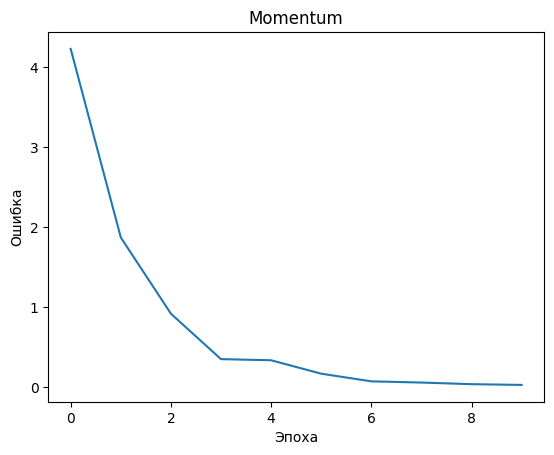

In [ ]:
import matplotlib.pyplot as plt

plt.plot(momentum_loss_history)
plt.xlabel("Эпоха")
plt.ylabel("Ошибка")
plt.title("Momentum")
plt.show()

# Nesterov

In [ ]:
# модель
nesterov_model = nn.Linear(1, 1)

criterion = nn.MSELoss()

nesterov_optimizer = torch.optim.SGD(nesterov_model.parameters(), lr=0.1, momentum=0.9, nesterov=True) # добавляем nesterov

nesterov_loss_history = [] # сюда записываем историю вычислений

# обучение
for epoch in range(10):
    epoch_loss = 0

    for X_batch, y_batch in dataloader:
        nesterov_optimizer.zero_grad()             # обнуляем градиенты
        y_pred = nesterov_model(X_batch)           # делаем предсказание
        loss = criterion(y_pred, y_batch) # вычисляем ошибку

        loss.backward()                   # вычисляем градиенты
        nesterov_optimizer.step()                  # делаем шаг градиентного спуска

        epoch_loss += loss.item()         # записываем историю вычислений за конкретную итерацию

    # усредним loss по батчам за каждую итерацию и запишем в историю
    epoch_loss /= len(dataloader)
    nesterov_loss_history.append(epoch_loss)

    print(f"Эпоха {epoch}: ошибка = {epoch_loss:.4f}")

Эпоха 0: ошибка = 2.2395
Эпоха 1: ошибка = 0.1280
Эпоха 2: ошибка = 0.0220
Эпоха 3: ошибка = 0.0107
Эпоха 4: ошибка = 0.0078
Эпоха 5: ошибка = 0.0081
Эпоха 6: ошибка = 0.0079
Эпоха 7: ошибка = 0.0089
Эпоха 8: ошибка = 0.0110
Эпоха 9: ошибка = 0.0077


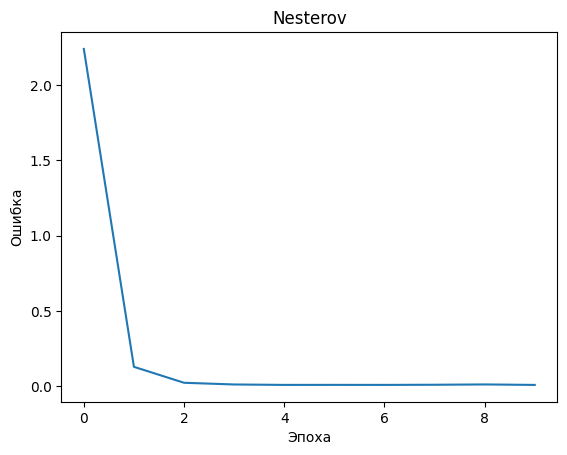

In [ ]:
plt.plot(nesterov_loss_history)
plt.xlabel("Эпоха")
plt.ylabel("Ошибка")
plt.title("Nesterov")
plt.show()

# Adagrad

In [ ]:
adagrad_model = nn.Linear(1, 1)

criterion = nn.MSELoss()

adagrad_optimizer = torch.optim.Adagrad(adagrad_model.parameters(), lr=0.2)

adagrad_loss_history = []

# обучение
for epoch in range(400):
    adagrad_optimizer.zero_grad()

    y_pred = adagrad_model(X)
    loss = criterion(y_pred, y)

    loss.backward()
    adagrad_optimizer.step()

    adagrad_loss_history.append(loss.item())

    print(f"Epoch {epoch}: loss = {loss.item():.4f}")

Epoch 0: loss = 14.0245
Epoch 1: loss = 12.1885
Epoch 2: loss = 11.0428
Epoch 3: loss = 10.1867
Epoch 4: loss = 9.4975
Epoch 5: loss = 8.9193
Epoch 6: loss = 8.4210
Epoch 7: loss = 7.9834
Epoch 8: loss = 7.5936
Epoch 9: loss = 7.2427
Epoch 10: loss = 6.9238
Epoch 11: loss = 6.6320
Epoch 12: loss = 6.3633
Epoch 13: loss = 6.1145
Epoch 14: loss = 5.8831
Epoch 15: loss = 5.6670
Epoch 16: loss = 5.4646
Epoch 17: loss = 5.2742
Epoch 18: loss = 5.0948
Epoch 19: loss = 4.9253
Epoch 20: loss = 4.7646
Epoch 21: loss = 4.6122
Epoch 22: loss = 4.4672
Epoch 23: loss = 4.3290
Epoch 24: loss = 4.1972
Epoch 25: loss = 4.0712
Epoch 26: loss = 3.9507
Epoch 27: loss = 3.8352
Epoch 28: loss = 3.7245
Epoch 29: loss = 3.6182
Epoch 30: loss = 3.5160
Epoch 31: loss = 3.4177
Epoch 32: loss = 3.3231
Epoch 33: loss = 3.2320
Epoch 34: loss = 3.1441
Epoch 35: loss = 3.0593
Epoch 36: loss = 2.9775
Epoch 37: loss = 2.8984
Epoch 38: loss = 2.8220
Epoch 39: loss = 2.7481
Epoch 40: loss = 2.6767
Epoch 41: loss = 2.607

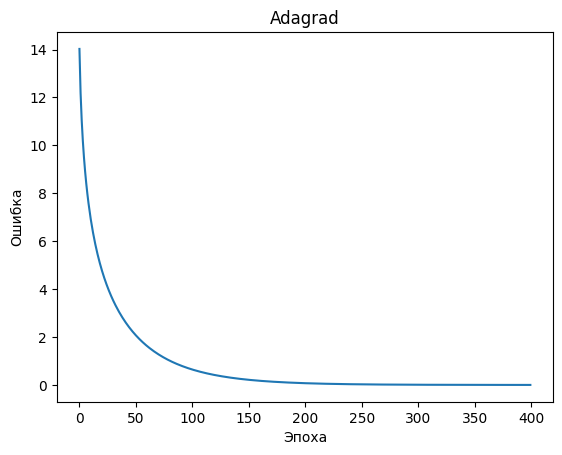

In [ ]:
plt.plot(adagrad_loss_history)
plt.xlabel("Эпоха")
plt.ylabel("Ошибка")
plt.title("Adagrad")
plt.show()

# RMSProp

In [ ]:
rms_model = nn.Linear(1, 1)

criterion = nn.MSELoss()

rms_optimizer = torch.optim.RMSprop(rms_model.parameters(), lr=0.1)

rms_loss_history = []

# обучение
for epoch in range(30):
    rms_optimizer.zero_grad()

    y_pred = rms_model(X)
    loss = criterion(y_pred, y)

    loss.backward()
    rms_optimizer.step()

    rms_loss_history.append(loss.item())

    print(f"Epoch {epoch}: loss = {loss.item():.4f}")

Epoch 0: loss = 18.6792
Epoch 1: loss = 8.3826
Epoch 2: loss = 4.4578
Epoch 3: loss = 2.5259
Epoch 4: loss = 1.4821
Epoch 5: loss = 0.8902
Epoch 6: loss = 0.5444
Epoch 7: loss = 0.3380
Epoch 8: loss = 0.2129
Epoch 9: loss = 0.1360
Epoch 10: loss = 0.0884
Epoch 11: loss = 0.0587
Epoch 12: loss = 0.0400
Epoch 13: loss = 0.0282
Epoch 14: loss = 0.0207
Epoch 15: loss = 0.0160
Epoch 16: loss = 0.0130
Epoch 17: loss = 0.0111
Epoch 18: loss = 0.0099
Epoch 19: loss = 0.0091
Epoch 20: loss = 0.0086
Epoch 21: loss = 0.0083
Epoch 22: loss = 0.0081
Epoch 23: loss = 0.0080
Epoch 24: loss = 0.0079
Epoch 25: loss = 0.0079
Epoch 26: loss = 0.0079
Epoch 27: loss = 0.0078
Epoch 28: loss = 0.0078
Epoch 29: loss = 0.0078


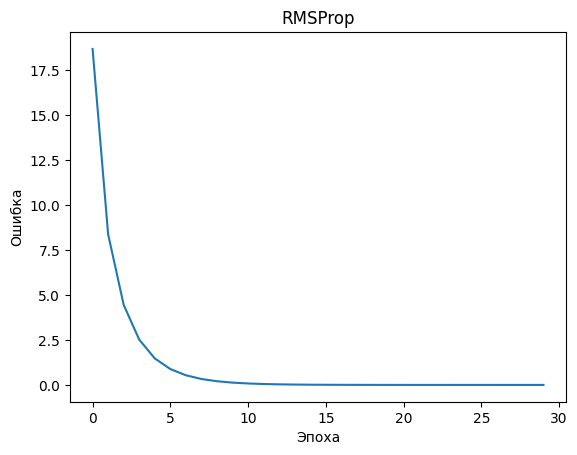

In [ ]:
plt.plot(rms_loss_history)
plt.xlabel("Эпоха")
plt.ylabel("Ошибка")
plt.title("RMSProp")
plt.show()

# Adam

In [ ]:
adam_model = nn.Linear(1, 1)

criterion = nn.MSELoss()

adam_optimizer = torch.optim.RMSprop(adam_model.parameters(), lr=0.1)

adam_loss_history = []

# обучение
for epoch in range(20):
    adam_optimizer.zero_grad()

    y_pred = adam_model(X)
    loss = criterion(y_pred, y)

    loss.backward()
    adam_optimizer.step()

    adam_loss_history.append(loss.item())

    print(f"Epoch {epoch}: loss = {loss.item():.4f}")

Epoch 0: loss = 19.4841
Epoch 1: loss = 9.4059
Epoch 2: loss = 5.5431
Epoch 3: loss = 3.5451
Epoch 4: loss = 2.3689
Epoch 5: loss = 1.6231
Epoch 6: loss = 1.1285
Epoch 7: loss = 0.7913
Epoch 8: loss = 0.5579
Epoch 9: loss = 0.3947
Epoch 10: loss = 0.2801
Epoch 11: loss = 0.1994
Epoch 12: loss = 0.1425
Epoch 13: loss = 0.1024
Epoch 14: loss = 0.0741
Epoch 15: loss = 0.0542
Epoch 16: loss = 0.0403
Epoch 17: loss = 0.0304
Epoch 18: loss = 0.0236
Epoch 19: loss = 0.0188


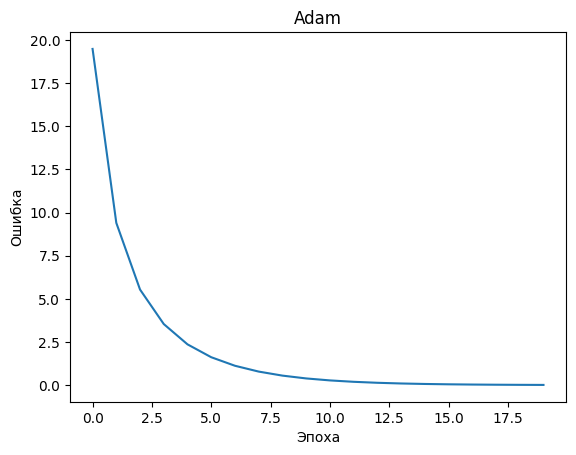

In [ ]:
plt.plot(adam_loss_history)
plt.xlabel("Эпоха")
plt.ylabel("Ошибка")
plt.title("Adam")
plt.show()

# Контроль шага обучения

In [ ]:
import torch

x = torch.tensor([5.0], requires_grad=True)

optimizer = torch.optim.SGD([x], lr=0.1)

# scheduler: уменьшаем learning rate каждые 2 шага

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

for i in range(6):
  optimizer.zero_grad()
  loss = x**2
  loss.backward()
  optimizer.step()
  scheduler.step()
  current_lr = optimizer.param_groups[0]['lr']
  print(f"iter {i+1}: x = {x.item():.4f}, lr = {current_lr}")

iter 1: x = 4.0000, lr = 0.1
iter 2: x = 3.2000, lr = 0.05
iter 3: x = 2.8800, lr = 0.05
iter 4: x = 2.5920, lr = 0.025
iter 5: x = 2.4624, lr = 0.025
iter 6: x = 2.3393, lr = 0.0125


In [ ]:
import torch

x = torch.tensor([5.0], requires_grad=True)

optimizer = torch.optim.SGD([x], lr=0.01)

# уменьшаем lr, если loss не улучшается
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',      # минимизируем функцию
    factor=0.5,      # γ (умножаем lr на 0.5)
    patience=2,      # k — сколько итераций ждать
    threshold=2e-1,  # ε — порог изменения
)

for i in range(10):
    optimizer.zero_grad()

    loss = x**2 + 0.1 * torch.sin(5 * x)
    loss.backward()

    optimizer.step()

    scheduler.step(loss.item())

    current_lr = optimizer.param_groups[0]['lr']

    print(f"iter {i+1}: x = {x.item():.4f}, loss = {loss.item():.6f}, lr = {current_lr}")


iter 1: x = 4.8950, loss = 24.986765, lr = 0.01
iter 2: x = 4.7932, loss = 23.900339, lr = 0.01
iter 3: x = 4.6954, loss = 22.882675, lr = 0.01
iter 4: x = 4.6019, loss = 21.946730, lr = 0.005
iter 5: x = 4.5572, loss = 21.092125, lr = 0.005
iter 6: x = 4.5133, loss = 20.696411, lr = 0.005
iter 7: x = 4.4703, loss = 20.315870, lr = 0.0025
iter 8: x = 4.4491, loss = 19.948412, lr = 0.0025
iter 9: x = 4.4281, loss = 19.769571, lr = 0.0025
iter 10: x = 4.4072, loss = 19.593132, lr = 0.0025


In [ ]:
import torch

x = torch.tensor([5.0], requires_grad=True)

alpha_max = 0.1
T_warmup = 3

optimizer = torch.optim.SGD([x], lr=alpha_max)

def lr_warmup(step):
    step = step + 1

    if step <= T_warmup:
        # warmup: линейный рост
        return step / T_warmup
    else:
        # уменьшение: 1/k
        return T_warmup / step

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_warmup)

for i in range(10):
    optimizer.zero_grad()

    loss = x**2
    loss.backward()

    optimizer.step()
    scheduler.step()

    current_lr = optimizer.param_groups[0]['lr']

    print(f"iter {i+1}: x = {x.item():.4f}, loss = {loss.item():.4f}, lr = {current_lr:.4f}")


iter 1: x = 4.6667, loss = 25.0000, lr = 0.0667
iter 2: x = 4.0444, loss = 21.7778, lr = 0.1000
iter 3: x = 3.2356, loss = 16.3575, lr = 0.0750
iter 4: x = 2.7502, loss = 10.4688, lr = 0.0600
iter 5: x = 2.4202, loss = 7.5637, lr = 0.0500
iter 6: x = 2.1782, loss = 5.8573, lr = 0.0429
iter 7: x = 1.9915, loss = 4.7444, lr = 0.0375
iter 8: x = 1.8421, loss = 3.9660, lr = 0.0333
iter 9: x = 1.7193, loss = 3.3934, lr = 0.0300
iter 10: x = 1.6161, loss = 2.9560, lr = 0.0273
